<a href="https://colab.research.google.com/github/DariaLaska/ml/blob/main/%D1%80%D0%B0%D1%81%D0%BA%D1%80%D0%B0%D1%88%D0%B8%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%B8%D0%B7%D0%BE%D0%B1%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from keras.layers import Conv2D, UpSampling2D, InputLayer
from keras.models import Sequential
import numpy as np
from google.colab import drive
from PIL import Image
import matplotlib.pyplot as plt
import os
import shutil  # Библиотека для работы с файлами
import moviepy.editor as mpy  # Библиотека для записи видео
import glob  # расширение для использования Unix обозначений при задании пути к файлу
import cv2

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def makeDataset(im):
  height, width = im.shape[:2]
  lab = cv2.cvtColor(im, cv2.COLOR_RGB2LAB)
  lab = np.float32(np.array(lab)) / 255

  # Разделим на xTrain и yTrain
  X = lab[:,:,0] # xTrain - это только канал яркости
  Y = lab[:,:,1:] # yTrain - это два цветоразностных канала

  X = X.reshape(height, width, 1)
  Y = Y.reshape(height, width, 2)

  return X, Y

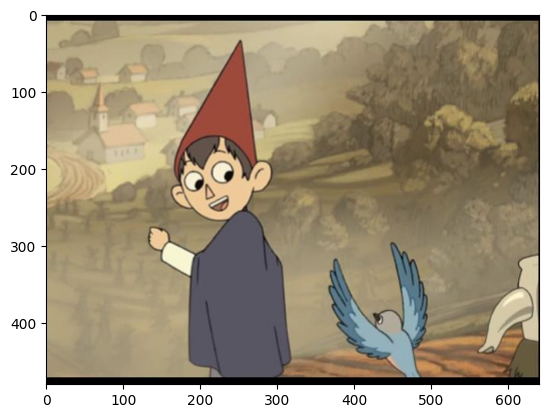

Ширина: 640  Высота: 480


In [ ]:
imgFile = "/content/drive/MyDrive/Colab Notebooks/ML/vid_minimini/frame0000_0035.jpg"

img = cv2.cvtColor(cv2.imread(imgFile), cv2.COLOR_BGR2RGB)
height, width = img.shape[:2]

plt.imshow(img)
plt.show()

print("Ширина:", width, " Высота:", height)

#Augmentation

In [ ]:
def transform_on_self(image: Image, transformed: Image) -> Image:
    result = image.copy()
    result.paste(transformed, (0, 0), transformed)
    return result

def crop(image: Image, x_shift: int, y_shift: int) -> Image:
    w, h = image.size
    shifted_image = Image.new('RGBA', (w, h), (0, 0, 0, 0))
    shifted_image.paste(image, (x_shift, y_shift))
    return shifted_image


def rotate(image: Image, angle: int) -> Image:
    result = image.copy()
    result = image.rotate(angle)
    return result

In [ ]:
from PIL import Image

def zoom(image: Image, koeff: int):

    width, height = image.size

    # Коэффициент зума (например, 2 — увеличение в 2 раза)
    zoom_factor = koeff

    # choice = random.choice([1, 2])

    # if choice==1: #smaller oom
    #     new_size = (width // zoom_factor, height // zoom_factor)
    #     smaller = image.resize(new_size, Image.LANCZOS)
    #     zoomed = Image.new('RGB', (width, height), (0, 0, 0))
    #     offset = ((width - new_size[0]) // 2, (height - new_size[1]) // 2)
    #     zoomed.paste(smaller, offset)
    # else: # bigger zoom
    crop_size = (width // zoom_factor, height // zoom_factor)
    left = (width - crop_size[0]) // 2
    top = (height - crop_size[1]) // 2
    right = left + crop_size[0]
    bottom = top + crop_size[1]

    cropped = image.crop((left, top, right, bottom))
    zoomed = cropped.resize((width, height), Image.LANCZOS)

    # Сохраняем результат
    return zoomed


In [ ]:
import random

def augment(orig_image):
    result = []
    for i in range(80):
        x_shift = random.randint(-60, 45)
        y_shift = random.randint(-60, 45)
        angle =  random.randint(-15, 15)

        koeff = 1+random.uniform(0, 1)//10
        transformed = rotate(zoom(crop(orig_image, x_shift, y_shift), koeff), angle)
        transformed = transform_on_self(orig_image, transformed)
        result.append(transformed)
    return result

In [ ]:
dataset_path = '/content/drive/MyDrive/Colab Notebooks/ML/vid'
dataset = {d: [] for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))}

def to_image(cls_path: os.path, file_path: os.path) -> Image:
    full_path = os.path.join(cls_path, file_path)
    image = Image.open(full_path).convert('RGBA')
    return image

def save(image: Image, index_j: int) -> None:
    image = image.convert('RGB')
    path = os.path.join("/content/drive/MyDrive/Colab Notebooks/ML/aug_frame", f"frame0000_{index_j:0>4}.jpg")
    image.save(path)

In [ ]:
full_path = os.path.join(imgFile)
frame_for_aug = Image.open(full_path).convert('RGBA')
mini_frame_for_aug = frame_for_aug.resize((640, 480)) #640*480 #960,540

In [ ]:
np.asarray(mini_frame_for_aug).shape

(480, 640, 4)

In [ ]:
#img
for j, aug in enumerate(augment(mini_frame_for_aug)):
    print(j)
    save(aug, j)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79


# Make dataset

In [ ]:
frame_for_aug = Image.open("/content/drive/MyDrive/Colab Notebooks/ML/aug_frame/frame0000_0010.jpg").convert('RGBA')
np.asarray(frame_for_aug).shape

(480, 640, 4)

In [ ]:
X = []
Y = []
imgFold = "/content/drive/MyDrive/Colab Notebooks/ML/aug_frame/"
for i in range(10, 80):
    #frame0000_0009.jpg
    path = os.path.join("/content/drive/MyDrive/Colab Notebooks/ML/aug_frame/", f"frame0000_{i:0>4}.jpg")
    print(path)
    #/content/drive/MyDrive/Colab Notebooks/ML/aug_frame/frame0000_0080.jpg
    i = cv2.imread(path)
    img = cv2.cvtColor(i, cv2.COLOR_BGR2RGB)

    full_path = os.path.join(imgFile)
    frame_for_aug = Image.open(full_path).convert('RGBA')
    mini_frame_for_aug = frame_for_aug.resize((640, 480))

    x, y = makeDataset(img)
    X.append(x)
    Y.append(y)

/content/drive/MyDrive/Colab Notebooks/ML/aug_frame/frame0000_0010.jpg
/content/drive/MyDrive/Colab Notebooks/ML/aug_frame/frame0000_0011.jpg
/content/drive/MyDrive/Colab Notebooks/ML/aug_frame/frame0000_0012.jpg
/content/drive/MyDrive/Colab Notebooks/ML/aug_frame/frame0000_0013.jpg
/content/drive/MyDrive/Colab Notebooks/ML/aug_frame/frame0000_0014.jpg
/content/drive/MyDrive/Colab Notebooks/ML/aug_frame/frame0000_0015.jpg
/content/drive/MyDrive/Colab Notebooks/ML/aug_frame/frame0000_0016.jpg
/content/drive/MyDrive/Colab Notebooks/ML/aug_frame/frame0000_0017.jpg
/content/drive/MyDrive/Colab Notebooks/ML/aug_frame/frame0000_0018.jpg
/content/drive/MyDrive/Colab Notebooks/ML/aug_frame/frame0000_0019.jpg
/content/drive/MyDrive/Colab Notebooks/ML/aug_frame/frame0000_0020.jpg
/content/drive/MyDrive/Colab Notebooks/ML/aug_frame/frame0000_0021.jpg
/content/drive/MyDrive/Colab Notebooks/ML/aug_frame/frame0000_0022.jpg
/content/drive/MyDrive/Colab Notebooks/ML/aug_frame/frame0000_0023.jpg
/conte

In [ ]:
# X, Y = makeDataset(img)

X = np.asarray(X)
Y = np.asarray(Y)

print(X.shape)
print(Y.shape)

(70, 480, 640, 1)
(70, 480, 640, 2)


In [ ]:
height, width = X.shape[1:3]

print(height, width)

480 640


In [ ]:
# print(np.asarray(Y).shape)

In [ ]:
# L_arr = [X[(...,0)]*255 for x in X]
# L_arr

In [ ]:
# # Посмотрим, что твориться в каждом из каналов

# L_arr = [X[(...,0)]*255 for x in X]

# L = Image.fromarray(L_arr.reshape(height, width)).convert('RGB');

# A_arr = [Y[(...,0)]*255 for y in Y]
# A = Image.fromarray(A_arr.reshape(height, width)).convert('RGB');

# B_arr = Y[(...,1)]*255
# B = Image.fromarray(B_arr.reshape(height, width)).convert('RGB');

# plt.imshow(L)
# plt.show()

# plt.imshow(A)
# plt.show()

# plt.imshow(B)
# plt.show()

In [ ]:
# i = [ [1], [2], [3], [4] ]
# print(i)

In [ ]:
# i = np.array([ [128, 34], [123, 56], [78, 66] ])
# #print(i)
# print(i[(...,1)])

# b = [ 0, -1, 200, 289 ]
# print(np.clip(b, 0, 255))


In [ ]:
model = Sequential()

# Encoder
model.add(InputLayer(input_shape=(height, width, 1)))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same', strides=2))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same', strides=2))
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(256, (3, 3), activation='relu', padding='same', strides=2))
model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(512, (3, 3), activation='relu', padding='same', strides=2))
model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(512, (3, 3), activation='relu', padding='same', strides=2))
# model.add(Conv2D(1024, (3, 3), activation='relu', padding='same'))
# model.add(Conv2D(1024, (3, 3), activation='relu', padding='same'))

model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))

# Decoder
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(2, (3, 3), activation='tanh', padding='same'))
model.add(UpSampling2D((2, 2)))


model.compile(optimizer='adam', loss='mse')
model.summary()

  warnings.warn(



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 480, 640, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 240, 320, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 240, 320, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 240, 320, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 120, 160, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 120, 160, 256)  │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 120, 160, 256)  │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 60, 80, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 80, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 60, 80, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 30, 40, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 30, 40, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 30, 40, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 15, 20, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 15, 20, 128)    │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 15, 20, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 30, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 30, 40, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 30, 40, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 60, 80, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 60, 80, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 60, 80, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 120, 160, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 120, 160, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 120, 160, 64)   │        36,92

 Total params: 17,056,290 (65.06 MB)

 Trainable params: 17,056,290 (65.06 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
new_height =  480
new_width = 640

In [ ]:
xTrain = X.reshape(70, new_height, new_width, 1)
yTrain = Y.reshape(70, new_height, new_width, 2)

print(xTrain.shape)
print(yTrain.shape)

(70, 480, 640, 1)
(70, 480, 640, 2)


In [ ]:
# Тренируем нейронку

model.fit(x=xTrain, y=yTrain, batch_size=1, epochs=20)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 42s 115ms/step - loss: 0.1117
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - loss: 0.0011
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 8.7516e-04
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - loss: 8.2777e-04
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - loss: 8.2860e-04
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - loss: 9.3420e-04
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - loss: 8.9937e-04
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - loss: 8.5805e-04
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - loss: 7.8464e-04
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - loss: 6.8069e-04
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - loss: 4.5784e-04
Epoch 12/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - loss: 3.0971e-04
Epoch 13/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - loss: 2.5557e-04
Epoch 14/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - loss: 2.2979e-04
Epoch 15

In [ ]:
def decodeImage(x, ab_predict):
  a = ab_predict[(...,0)] * 255;
  b = ab_predict[(...,1)] * 255;

  a = np.clip(a, 0, 255)
  b = np.clip(b, 0, 255)

  # Создадим пустой массив, с размерами нашей картинки и тремя каналами цвета
  lab = np.zeros((height, width, 3))

  # Копируем в массив данные в нужной последовательности
  lab[:,:,0] = x * 255
  lab[:,:,1] = a
  lab[:,:,2] = b

  # Преобразуем к целым 8-битным числам без знака
  lab = np.uint8(lab)

  rgb = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

  return rgb

3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 9s/step


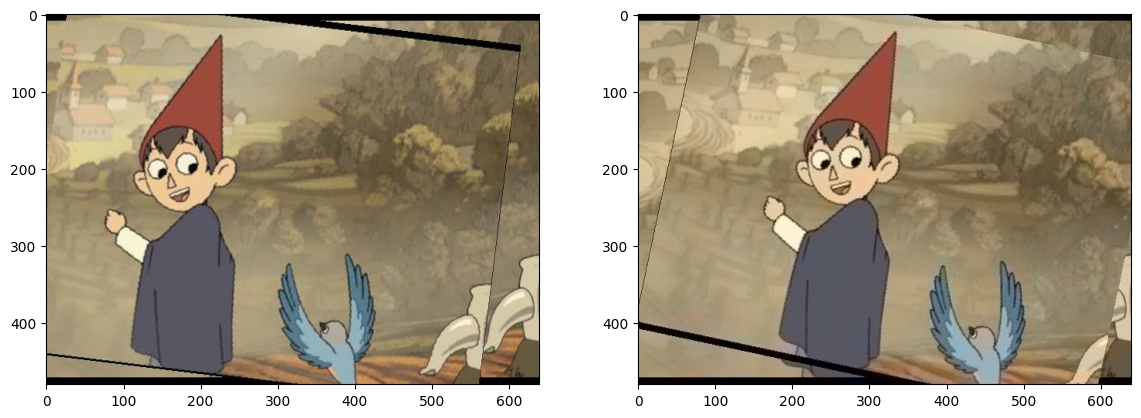

In [ ]:
output = model.predict(xTrain)

rgb = decodeImage(X[0][(...,0)], output[0])

plt.figure(figsize=(14, 14))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.subplot(1, 2, 2)
plt.imshow(rgb)



# Раскрашиваем все кадры нашего видео



In [ ]:
frameFiles = "/content/drive/MyDrive/Colab Notebooks/ML/vid_minimini"
videoDir = '/content/drive/MyDrive/Colab Notebooks/ML/new_video'

In [ ]:
# Получаем список всех фрэймов
framesList = os.listdir(frameFiles)

c = 1
s = len(framesList)

for f in framesList:
  inpFile = frameFiles+"/"+f
  outFile = videoDir+"/"+f

  print(c, "("+str(s)+")  ", outFile)

  img = cv2.cvtColor(cv2.imread(inpFile, cv2.IMREAD_GRAYSCALE), cv2.COLOR_BGR2RGB)
  height, width = img.shape[:2]

  # Переводим изображение в модель LAB и берем только яркостную компоненту
  x, _ = makeDataset(img)
  x = x.reshape(1, height, width, 1)

  # Раскрашиваем изображение с помощью нашей нейросети
  pred = model.predict(x)

  # Переводим вывод нейросети в палитру RGB
  rgb = decodeImage(x[(...,0)], pred[0])

  # Переводим фрейм в палитру BGR (так как все вспомогательные функции OpenCV работают именно в BGR)
  bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)

  # Записываем фрэйм в файл
  cv2.imwrite(outFile, bgr)

  c += 1

1 (191)   /content/drive/MyDrive/Colab Notebooks/ML/new_video/frame0000_0002.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
2 (191)   /content/drive/MyDrive/Colab Notebooks/ML/new_video/frame0000_0001.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
3 (191)   /content/drive/MyDrive/Colab Notebooks/ML/new_video/frame0000_0000.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
4 (191)   /content/drive/MyDrive/Colab Notebooks/ML/new_video/frame0000_0005.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
5 (191)   /content/drive/MyDrive/Colab Notebooks/ML/new_video/frame0000_0004.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
6 (191)   /content/drive/MyDrive/Colab Notebooks/ML/new_video/frame0000_0006.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
7 (191)   /content/drive/MyDrive/Colab Notebooks/ML/new_video/frame0000_0007.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
8 (191)   /content/drive/MyDrive/Colab Notebooks/ML/new_video/frame0000_0003.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
9 (191)   /content/drive/MyDrive/Colab Notebooks/M

In [ ]:
# if os.path.isdir(videoDir):
#   shutil.rmtree(videoDir+'/')  # удаляем каталог вместе с содержимым
# os.mkdir(videoDir) # Создаем директорию для выгрузке раскрашенных файлов

In [ ]:
# Собираем из отдельных кадров наше видео

if os.path.isdir(videoDir):
    video_name = 'second_video.mp4'
    fps = 30

    files = glob.glob(videoDir + '/*.jpg')
    files.sort()

    file_list = []
    for i in files:
        for j in range(2):
            file_list.append(i)

    clip = mpy.ImageSequenceClip(file_list, fps=fps)
    clip.write_videofile(video_name)

Moviepy - Building video second_video.mp4.
Moviepy - Writing video second_video.mp4



Moviepy - Done !
Moviepy - video ready second_video.mp4
